# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: PolynomialEmbedding (n=3)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [1]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import jax
import jax.numpy as jnp
import numpy as np
import optax
import torch
import quimb.tensor as qtn
from sklearn.metrics import auc
from jax.nn.initializers import *
import matplotlib.pyplot as plt

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *



from cascaded_tn.training.cascaded_model import *
from cascaded_tn.builders.dimension_calculator import DimensionCalculator

In [2]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
print("JAX devices:", jax.devices())
print("PyTorch CUDA:", torch.cuda.is_available())

JAX devices: [cuda(id=0), cuda(id=1)]
PyTorch CUDA: False


**Load 40 MHz dataset**

In [3]:
import utils.dataloader as d

inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #This should be false, otherwise there might be issues with reading the hdf5 files.

FALSE


In [17]:
batch_size = 2048
background = d.load_data(inputPath + "background_for_training.h5", batch_size=batch_size, shuffle=True, norm=True)

In [18]:
print("Background shape before:", next(iter(background)).shape)

Background shape before: torch.Size([2048, 56])


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [ ]:
# define model parameters
L = 56
initializer = jax.nn.initializers.variance_scaling(scale=2.0, mode='fan_avg', distribution='uniform')
key = jax.random.PRNGKey(42)

k = 1
# embedding = PolynomialEmbedding(degree=k, n=1, include_bias=True)
embedding = TrigonometricEmbedding(k)
phys_dim = (embedding.dim, embedding.dim) # = (2k, 2k) for trigonometric embedding, (k+1, k+1) for polynomial embedding

add_identity = True
boundary='obc' # 'pbc' or 'obc' = periodic or open boundary conditions

In [7]:
from cascaded_tn.training.regularization import LogAnomalyRegNorm

alpha = 0.2
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = lambda P: alpha * LogAnomalyRegNorm(
        P, 
        alpha_spectral=0.01,
        alpha_smooth=0.2,
        alpha_sparse=0.1
    )
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [8]:
# calc = DimensionCalculator(debug=False)
autoencoder = create_trainable_autoencoder(
    # layer_dims=calc.suggest_cyclic_compatible_dims(56, 3, target_output=3),
    layer_dims=[56,19,7,3],
    bond_dims=[8,7,5],
    cyclic=False,
    symmetric=False,
    key=key,
    debug=False,
    initializer=initializer,
    phys_dim=phys_dim,
    add_identity=add_identity,
    boundary=boundary,
    optimizer=optax.adam,
    learning_rate=1e-4,
    loss_function=loss_combined,
)

In [9]:
print("Number of parameters in the model are: ", autoencoder.nparams())

Number of parameters in the model are:  11816


In [10]:
def loss_fn(data, targets, *params):

    temp_model = autoencoder.copy()

    # Update with new parameters
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)

    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)

    # Apply the cascade (compression only for now)
    compressed = temp_model.cascade.apply(tn_i)
    
    return autoencoder.loss(compressed, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

In [11]:
# Split into two parts: data-dependent and model-dependent

@jax.jit
def compute_error_batch(sample_batch, *params):
    """JIT-compiled error computation for the batch"""
    def single_error(data_point, *p):
        # Create temp model and update params
        temp_model = autoencoder.copy()
        for tensor, param in zip(temp_model.tensors, p):
            tensor.modify(data=param)
        
        # Compute error for single point
        tn_i = embed(data_point, embedding)
        compressed = temp_model.cascade.apply(tn_i)
        return LogQuadNorm(compressed, tn_i)
    
    # Vectorize over batch
    errors = jax.vmap(single_error, in_axes=[0] + [None]*len(params))(sample_batch, *params)
    return jnp.mean(errors)

# Separate function for regularization (computed ONCE, not per batch item!)
def compute_reg_components_fast(*params):
    """Compute regularization terms - only needs to run once per parameter update"""
    # Pre-compute tensor shapes and indices outside JIT
    tensor_shapes = [t.shape for t in autoencoder.tensors]
    layer_boundaries = []  # Store which tensors belong to which layer
    
    # Figure out tensor-to-layer mapping
    idx = 0
    for op in autoencoder.cascade.operators:
        if hasattr(op.implementation, 'tensors'):
            n_tensors = len(op.implementation.tensors)
            layer_boundaries.append((idx, idx + n_tensors))
            idx += n_tensors
    
    @jax.jit
    def reg_terms(params_concat):
        """JIT-compiled regularization computation"""
        # Split concatenated params back into individual tensors
        params_list = []
        start = 0
        for shape in tensor_shapes:
            size = np.prod(shape)
            param = params_concat[start:start+size].reshape(shape)
            params_list.append(param)
            start += size
        
        reg_spectral = reg_smooth = reg_sparse = 0.0
        prev_norm = None
        
        # Process each layer
        for layer_idx, (start_idx, end_idx) in enumerate(layer_boundaries):
            layer_tensors = params_list[start_idx:end_idx]
            
            # 1. Spectral regularization
            for tensor in layer_tensors:
                if len(tensor.shape) >= 2:
                    matrix = tensor.reshape(tensor.shape[0], -1)
                    s = jnp.linalg.svd(matrix, compute_uv=False)
                    effective_rank = jnp.sum(s) ** 2 / (jnp.sum(s ** 2) + 1e-8)
                    reg_spectral += (1.0 / (effective_rank + 0.1))
            
            # 2. Layer smoothness
            curr_norm = sum(jnp.sum(t**2) for t in layer_tensors)
            if layer_idx > 0 and prev_norm is not None:
                reg_smooth += jnp.abs(jnp.log(curr_norm / (prev_norm + 1e-8)))
            prev_norm = curr_norm
            
            # 3. Bottleneck sparsity (last layer)
            if layer_idx == len(layer_boundaries) - 1:
                for tensor in layer_tensors:
                    reg_sparse += jnp.sum(jnp.abs(tensor))
        
        return reg_spectral, reg_smooth, reg_sparse
    
    # Concatenate all parameters into single array
    params_concat = jnp.concatenate([p.flatten() for p in params])
    
    return reg_terms(params_concat)

In [12]:
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+autoencoder.L)), in_axes=[0, None] + [None]*autoencoder.L), backend=autoencoder.device)

params = autoencoder.arrays
autoencoder.step, autoencoder.opt_state = autoencoder.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)

In [13]:
@jax.jit
def train_step_jitted(params, opt_state, batch):
    # Compute loss and gradients in one go
    loss_val, grads = jax.value_and_grad(
        lambda *p: jnp.mean(jax.vmap(loss_fn, in_axes=[0, None] + [None]*len(p))(batch, None, *p)),
        argnums=range(len(params))
    )(*params)
    
    # Update parameters
    grads_dict = {i: g for i, g in enumerate(grads)}
    params_dict = {i: p for i, p in enumerate(params)}
    
    updates, opt_state = autoencoder.optimizer.update(grads_dict, opt_state)
    params_dict = optax.apply_updates(params_dict, updates)
    
    return tuple(params_dict.values()), opt_state, loss_val

In [ ]:
from tqdm import tqdm
import time

epochs = 10
history = {'learning_rate': 1e-4, 
            'loss': [], 
            'error_term' : [],
            'spectral_term': [],
            'smooth_term': [],
            'sparse_term': [],
            'epoch_time': [], 
            'unfinished': True}

autoencoder.cascade.debug = False
autoencoder.debug = False
for op in autoencoder.cascade.operators:
    op.debug = False
    if hasattr(op, 'implementation'):
        op.implementation.debug = False

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    sample_batch = None  # Store one batch for loss component analysis

    for i, batch in enumerate(tqdm(background, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        if sample_batch is None:  # Save first batch for analysis
            sample_batch = batch
        params = autoencoder.arrays
        params, autoencoder.opt_state, loss = train_step_jitted(params, autoencoder.opt_state, batch)
        autoencoder.update_tensors(params)
        epoch_loss += loss

    end_time = time.time()
    avg_loss = epoch_loss / len(background)

    # Compute individual loss terms for monitoring using the existing loss functions
    # Get current model parameters
    current_params = autoencoder.arrays

    error_val = float(compute_error_batch(sample_batch, *autoencoder.arrays))

    reg_spectral, reg_smooth, reg_sparse = compute_reg_components_fast(*autoencoder.arrays)
    reg_spectral = float(reg_spectral)
    reg_smooth = float(reg_smooth)
    reg_sparse = float(reg_sparse)

    history['loss'].append(avg_loss)
    history['error_term'].append(error_val)
    history['spectral_term'].append(reg_spectral)
    history['smooth_term'].append(reg_smooth)
    history['sparse_term'].append(reg_sparse)
    history['epoch_time'].append(end_time - start_time)
    
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.6f} | Error: {error_val:.6f} | Spectral: {reg_spectral:.6f} | Smooth: {reg_smooth:.6f} | Sparse: {reg_sparse:.6f} | Time: {end_time - start_time:.2f}s")
    history['unfinished'] = False  # training completed successfully


Epoch 1/10: 100%|██████████| 1954/1954 [07:13<00:00,  4.50it/s]


[Epoch 1] Loss: 7.670223 | Error: 1.962762 | Spectral: 16.338271 | Smooth: 2.381690 | Sparse: 93.911123 | Time: 433.94s


Epoch 2/10: 100%|██████████| 1954/1954 [07:11<00:00,  4.53it/s]


[Epoch 2] Loss: 1.799467 | Error: 1.600576 | Spectral: 16.338102 | Smooth: 2.381415 | Sparse: 93.917241 | Time: 431.70s


Epoch 3/10: 100%|██████████| 1954/1954 [07:11<00:00,  4.53it/s]


[Epoch 3] Loss: 1.407718 | Error: 1.107709 | Spectral: 16.336604 | Smooth: 2.381291 | Sparse: 93.966551 | Time: 431.72s


Epoch 4/10:  41%|████      | 794/1954 [02:54<04:17,  4.50it/s]

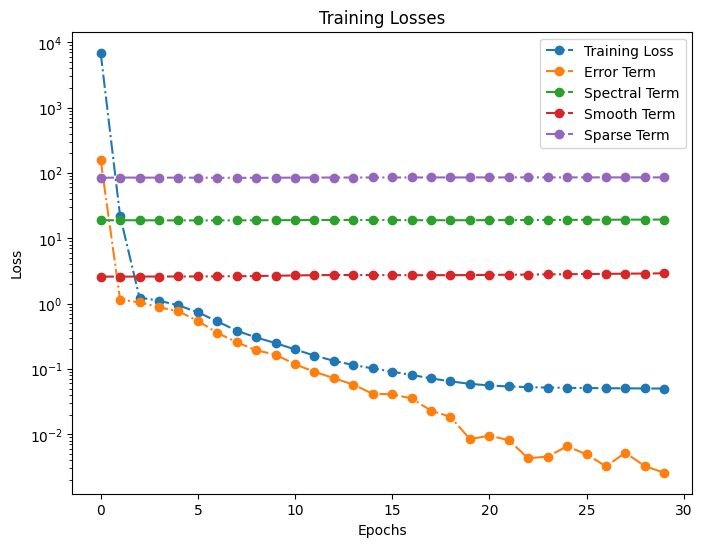

In [ ]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='Training Loss')
plt.plot(range(len(history['error_term'])), history['error_term'], linestyle="-.", marker='o', label='Error Term')
plt.plot(range(len(history['spectral_term'])), history['spectral_term'], linestyle="-.", marker='o', label='Spectral Term')
plt.plot(range(len(history['smooth_term'])), history['smooth_term'], linestyle="-.", marker='o', label='Smooth Term')
plt.plot(range(len(history['sparse_term'])), history['sparse_term'], linestyle="-.", marker='o', label='Sparse Term')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.savefig('training_loss.png', dpi=300)

**Evaluate**

In [ ]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=True, norm=True)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=True, norm=True)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=True, norm=True)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=True, norm=True)

In [ ]:
@jax.jit
def loss_error_only(data, targets, *params):
    """Compute only LogQuadNorm error term for anomaly scoring"""
    # Create temp model with updated parameters
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    # Apply the cascade
    compressed = temp_model.cascade.apply(tn_i)
    
    # Return only error term (no regularization)
    return LogQuadNorm(compressed, tn_i)

# Vectorize it for batch processing
loss_func_error = jax.jit(jax.vmap(loss_error_only, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples


In [ ]:
# Run the evaluation on bkg and signals
bkg_score = evaluate_model(autoencoder, background, loss_func_error, embedding, verbose=True)
a4l_score = evaluate_model(autoencoder, a4l, loss_func_error, embedding, verbose=True)
lq_score = evaluate_model(autoencoder, lq, loss_func_error, embedding, verbose=True)
htnu_score = evaluate_model(autoencoder, htnu, loss_func_error, embedding, verbose=True)
htt_score  = evaluate_model(autoencoder, htt, loss_func_error, embedding, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:10<00:00,  6.39it/s]


**Plot anomaly scores and ROC curve**

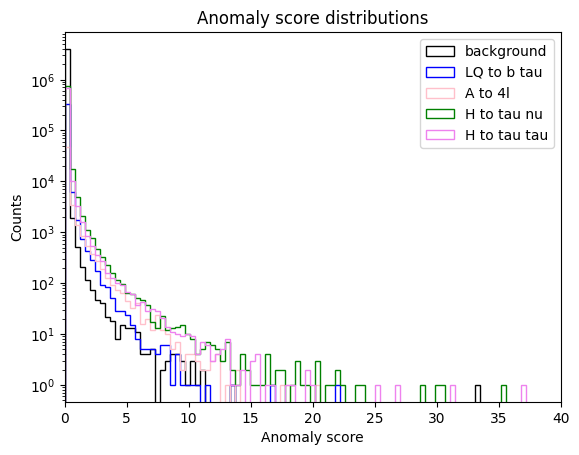

In [ ]:
plt.figure()
plt.yscale('log')
xmax = 40
bins = np.linspace(0, xmax, 100)
plt.hist(bkg_score, bins=bins, histtype='step', color='black', label='background')
plt.hist(lq_score, bins=bins, histtype='step', color='blue', label='LQ to b tau')
plt.hist(a4l_score, bins=bins, histtype='step', color='pink', label='A to 4l')
plt.hist(htnu_score, bins=bins, histtype='step', color='green', label='H to tau nu')
plt.hist(htt_score, bins=bins, histtype='step', color='violet', label='H to tau tau')
plt.title('Anomaly score distributions')
plt.xlim([0, xmax])
plt.xlabel('Anomaly score')
plt.ylabel('Counts')
plt.legend()
plt.legend()
plt.savefig('anomaly_scores.png', dpi=300)

In [ ]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 5.865452929453332


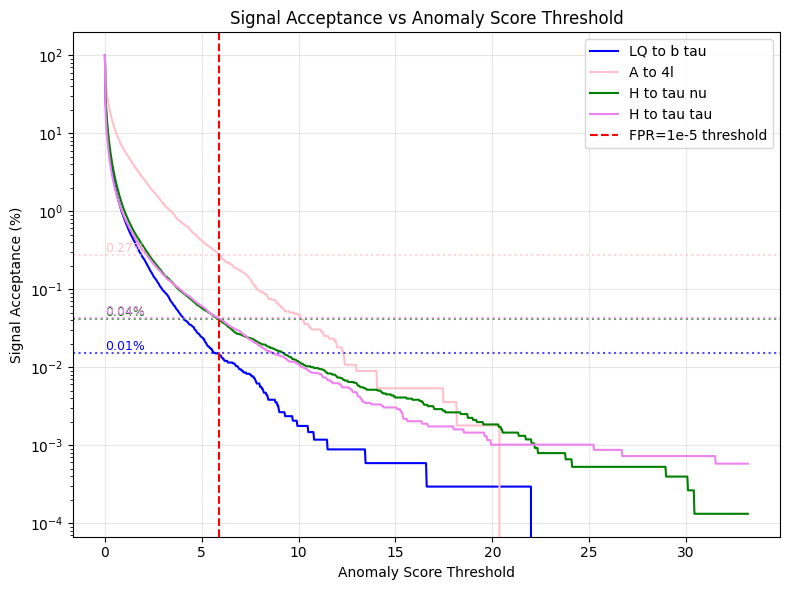

In [ ]:
# Compute acceptance curves for each signal as a function of anomaly score threshold
thresholds = np.linspace(np.min(bkg_score), np.max(bkg_score), 1000)

def acceptance_curve(scores, thresholds):
   return np.array([(scores >= t).mean() for t in thresholds])

accept_lq = acceptance_curve(lq_score, thresholds)
accept_a4l = acceptance_curve(a4l_score, thresholds)
accept_htt = acceptance_curve(htt_score, thresholds)
accept_htnu = acceptance_curve(htnu_score, thresholds)

plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(thresholds, accept_lq * 100, color="blue", label="LQ to b tau")
plt.plot(thresholds, accept_a4l * 100, color="pink", label="A to 4l")
plt.plot(thresholds, accept_htnu * 100, color="green", label="H to tau nu")
plt.plot(thresholds, accept_htt * 100, color="violet", label="H to tau tau")
# Add horizontal lines and text for acceptance at score_threshold for each signal
for accept, label, color in [
   (accept_lq, "LQ to b tau", "blue"),
   (accept_a4l, "A to 4l", "pink"),
   (accept_htnu, "H to tau nu", "green"),
   (accept_htt, "H to tau tau", "violet"),
]:
   idx = np.searchsorted(thresholds, score_threshold, side="left")
   if idx >= len(accept):
      idx = -1
   acc_val = accept[idx] * 100
   plt.axhline(y=acc_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(thresholds[0], acc_val, f"{acc_val:.2f}%", color=color, va="bottom", fontsize=9)
plt.axvline(score_threshold, color='red', linestyle='--', label='FPR=1e-5 threshold')
plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Signal Acceptance (%)")
plt.title("Signal Acceptance vs Anomaly Score Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('signal_acceptance.png', dpi=300)

In [ ]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

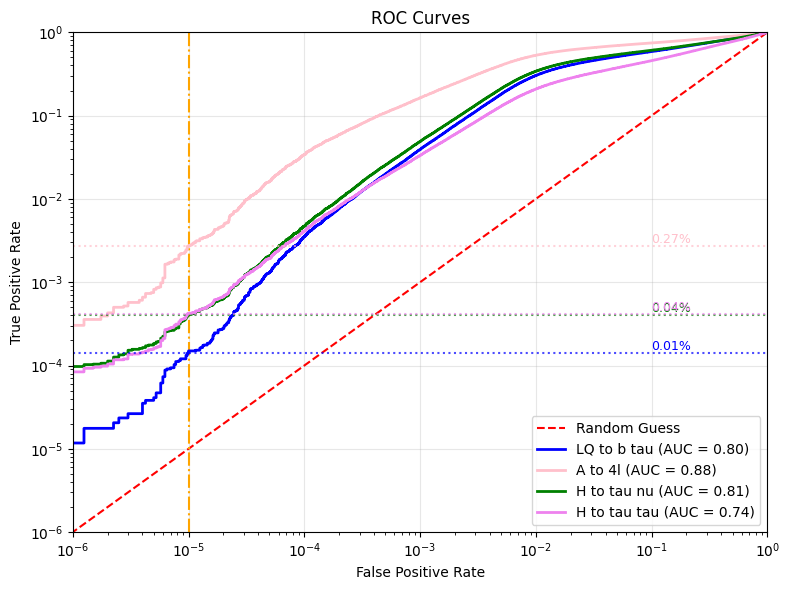

In [ ]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="left")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)